# Detection Analysis: Matched Lines vs K-After-Edit

Analyzes both windowing methods extracted by script 04.

**Vector 1: Matched Lines** - Response start to last edited line  
**Vector 2: K-After-Edit** - 24 tokens after last edited line

**Analyses:**
- Performance comparison
- Distribution visualizations
- Metrics per vector

## 1. Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_ROOT = Path('..') / 'data'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'
MODEL_NAME = 'Qwen/Qwen3-4B'

RESULTS_ROOT.mkdir(exist_ok=True)

## 2. Load Pre-Extracted Vectors

In [2]:
# Load vectors extracted by script 04
with open(ARTIFACT_ROOT / 'vector_matched_lines.json') as f:
    vec_matched_cfg = json.load(f)
with open(ARTIFACT_ROOT / 'vector_k_after_edit.json') as f:
    vec_k_after_cfg = json.load(f)

print(f"Vector 1 (matched_lines): Layer {vec_matched_cfg['layer']}")
print(f"Vector 2 (k_after_edit): Layer {vec_k_after_cfg['layer']}, K={vec_k_after_cfg['k_tokens']}")

# Load dataset
with open(DATA_ROOT / 'off_policy.json') as f:
    dataset = json.load(f)

print(f"\nDataset: {len(dataset)} prompts")
print(f"On-policy: {sum(len(ex['on_policy']) for ex in dataset)} rollouts")
print(f"Off-policy: {sum(len(ex['off_policy']) for ex in dataset)} variants")

Vector 1 (matched_lines): Layer 35
Vector 2 (k_after_edit): Layer 31, K=24

Dataset: 40 prompts
On-policy: 200 rollouts
Off-policy: 600 variants


## 3. Load Model

In [3]:
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map='auto', torch_dtype='auto')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("Model loaded")

Loading Qwen/Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded


## 4. Compute Projections

In [4]:
def compute_projection(prompt_template: str, completion: str, vector: torch.Tensor, layer: int) -> float:
    """Compute projection onto unit vector."""
    unit_vec = torch.tensor(vector, dtype=torch.float32).to(model.device)
    unit_vec = unit_vec / (torch.linalg.norm(unit_vec) + 1e-8)
    
    full = prompt_template + completion
    inputs = tokenizer(full, return_tensors='pt').to(model.device)
    prompt_len = len(tokenizer(prompt_template)['input_ids'])
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, use_cache=False)
    
    hidden = outputs.hidden_states[layer + 1][0][prompt_len:]
    pooled = hidden.mean(dim=0).to(torch.float32)
    return float((pooled @ unit_vec).item())

# Test both vectors
results = []
for vec_name, cfg in [('matched_lines', vec_matched_cfg), ('k_after_edit', vec_k_after_cfg)]:
    print(f"\nTesting {vec_name}...")
    vector = cfg['vector']
    layer = cfg['layer']
    
    for ex in tqdm(dataset, desc=vec_name):
        prompt = ex['prompt_with_template']
        
        # On-policy
        for completion in ex['on_policy']:
            proj = compute_projection(prompt, completion, vector, layer)
            results.append({
                'vector': vec_name,
                'layer': layer,
                'type': 'on_policy',
                'projection': proj
            })
        
        # Off-policy
        for variant in ex['off_policy']:
            proj = compute_projection(prompt, variant['text_clipped'], vector, layer)
            results.append({
                'vector': vec_name,
                'layer': layer,
                'type': 'off_policy',
                'projection': proj
            })

results_df = pd.DataFrame(results)
print(f"\nCollected {len(results_df)} projections")


Testing matched_lines...


matched_lines:   0%|          | 0/40 [00:00<?, ?it/s]


Testing k_after_edit...


k_after_edit:   0%|          | 0/40 [00:00<?, ?it/s]


Collected 1600 projections


## 5. Compute Metrics

In [5]:
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return diff / (pooled + 1e-8)

metrics = []
for vec_name in results_df['vector'].unique():
    subset = results_df[results_df['vector'] == vec_name]
    on = subset[subset['type'] == 'on_policy']['projection'].values
    off = subset[subset['type'] == 'off_policy']['projection'].values
    
    threshold = (on.mean() + off.mean()) / 2
    on_acc = (on > threshold).mean()
    off_acc = (off <= threshold).mean()
    
    u_stat, p_val = mannwhitneyu(on, off, alternative='two-sided')
    auc = u_stat / (len(on) * len(off))
    
    metrics.append({
        'vector': vec_name,
        'layer': subset['layer'].iloc[0],
        'mean_on': on.mean(),
        'std_on': on.std(ddof=1),
        'mean_off': off.mean(),
        'std_off': off.std(ddof=1),
        'cohens_d': cohens_d(on, off),
        'auc': auc,
        'mann_whitney_p': p_val,
        'on_acc': on_acc,
        'off_acc': off_acc,
        'balanced_acc': (on_acc + off_acc) / 2,
        'num_on': len(on),
        'num_off': len(off)
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

# Save
metrics_df.to_csv(RESULTS_ROOT / 'detection_metrics.csv', index=False)
print(f"\nSaved metrics to {RESULTS_ROOT / 'detection_metrics.csv'}")

,vector,layer,mean_on,std_on,mean_off,std_off,cohens_d,auc,mann_whitney_p,on_acc,off_acc,balanced_acc,num_on,num_off
0,matched_lines,35,-0.577375,8.758845,-30.727040,12.955279,2.726514,0.961233,3.661866e-85,0.935,0.843333,0.889167,200,600
1,k_after_edit,31,-94.320041,7.663577,-109.991107,11.448063,1.608713,0.878508,5.852031e-58,0.925,0.758333,0.841667,200,600



Saved metrics to ../results/detection_metrics.csv


## 6. Visualizations

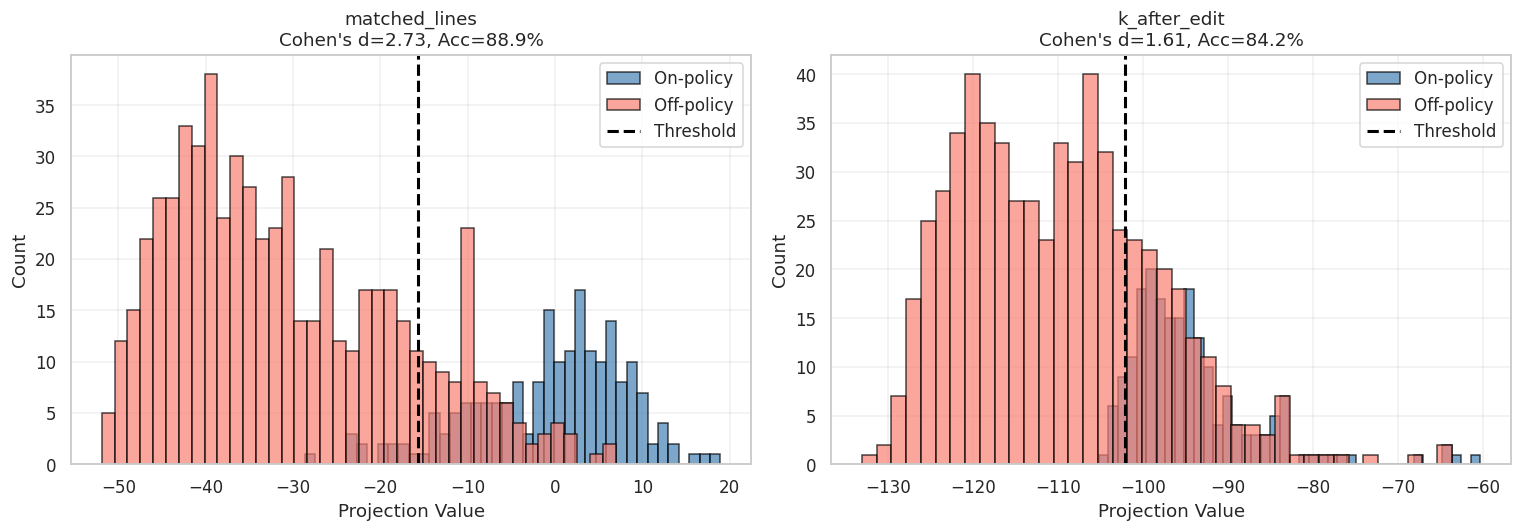

Saved visualization to ../results/projection_distributions.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, vec_name in enumerate(['matched_lines', 'k_after_edit']):
    ax = axes[idx]
    subset = results_df[results_df['vector'] == vec_name]
    on = subset[subset['type'] == 'on_policy']['projection']
    off = subset[subset['type'] == 'off_policy']['projection']
    
    ax.hist(on, bins=40, alpha=0.7, label='On-policy', color='steelblue', edgecolor='black')
    ax.hist(off, bins=40, alpha=0.7, label='Off-policy', color='salmon', edgecolor='black')
    
    threshold = (on.mean() + off.mean()) / 2
    ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
    
    metric = metrics_df[metrics_df['vector'] == vec_name].iloc[0]
    ax.set_xlabel('Projection Value')
    ax.set_ylabel('Count')
    ax.set_title(f"{vec_name}\nCohen's d={metric['cohens_d']:.2f}, Acc={metric['balanced_acc']*100:.1f}%")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_ROOT / 'projection_distributions.png', dpi=140)
plt.show()

print(f"Saved visualization to {RESULTS_ROOT / 'projection_distributions.png'}")

## 7. Summary

In [7]:
print("=" * 60)
print("DETECTION PERFORMANCE SUMMARY")
print("=" * 60)

for _, row in metrics_df.iterrows():
    print(f"\n{row['vector'].upper()}:")
    print(f"  Layer: {int(row['layer'])}")
    print(f"  Cohen's d: {row['cohens_d']:.3f}")
    print(f"  ROC AUC: {row['auc']:.3f}")
    print(f"  Balanced Accuracy: {row['balanced_acc']*100:.1f}%")
    print(f"  On-policy:  {row['mean_on']:7.2f} ± {row['std_on']:.2f}")
    print(f"  Off-policy: {row['mean_off']:7.2f} ± {row['std_off']:.2f}")

DETECTION PERFORMANCE SUMMARY

MATCHED_LINES:
  Layer: 35
  Cohen's d: 2.727
  ROC AUC: 0.961
  Balanced Accuracy: 88.9%
  On-policy:    -0.58 ± 8.76
  Off-policy:  -30.73 ± 12.96

K_AFTER_EDIT:
  Layer: 31
  Cohen's d: 1.609
  ROC AUC: 0.879
  Balanced Accuracy: 84.2%
  On-policy:   -94.32 ± 7.66
  Off-policy: -109.99 ± 11.45
